In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.5 MB 1.2 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.5 MB 1.4 MB/s eta 0:00:06
   ------------- -------------------------- 3.1/9.5 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 1.9 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 1.9 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 1.9 MB/s eta 0:00:03
   ----------------- -----


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
# ============================================
# GOLD-SILVER MEAN REVERSION ANALYSIS
# Step 1: Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statistical tests
from statsmodels.tsa.stattools import coint, adfuller

# Regression
import statsmodels.api as sm

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================
# Step 2: Load Gold & Silver Data
# ============================================

# Load the CSV file
df = pd.read_csv("C:/Users/pc/Desktop/Gold_Silver_Tableau_Data.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date
df = df.sort_values("Date").reset_index(drop=True)

# Display first 5 rows
df.head()

,Date,Adj Close_Gold,Daily_Return_Gold,Cumulative_Return_Gold,Investment_Value_Gold,Drawdown_Gold,Adj Close_Silver,Daily_Return_Silver,Cumulative_Return_Silver,Investment_Value_Silver,Drawdown_Silver,Year
0,2022-02-07,41.630001,0.072122,0.072122,100072.121623,0.0,61.770000,1.329408,1.329408,101329.408224,0.000000,2022
1,2022-02-08,41.820000,0.456398,0.528849,100528.849108,0.0,62.279999,0.825641,2.166025,102166.025154,0.000000,2022
2,2022-02-09,41.990002,0.406509,0.937508,100937.507737,0.0,62.770000,0.786772,2.969839,102969.838975,0.000000,2022
3,2022-02-10,42.169998,0.428665,1.370192,101370.191624,0.0,62.799999,0.047792,3.019050,103019.049895,0.000000,2022
4,2022-02-11,42.189999,0.047428,1.418270,101418.269650,0.0,62.360001,-0.700635,2.297263,102297.262618,-0.700635,2022


In [5]:
# ============================================
# Step 3: Prepare Gold & Silver Price Data
# ============================================

# Keep only the columns needed for mean-reversion analysis
prices = df[["Date", "Adj Close_Gold", "Adj Close_Silver"]].copy()

# Rename columns for easier use
prices.columns = ["Date", "Gold", "Silver"]

# Check for missing values
print("Missing values:")
print(prices.isnull().sum())

# Remove rows with missing Gold or Silver prices
prices = prices.dropna().reset_index(drop=True)

# Display dataset information
print("\nDataset shape:", prices.shape)

print("\nDate range:")
print(prices["Date"].min(), "to", prices["Date"].max())

# Display first 5 rows
prices.head()

Missing values:
Date      0
Gold      0
Silver    0
dtype: int64

Dataset shape: (1120, 3)

Date range:
2022-02-07 00:00:00 to 2026-08-18 00:00:00


,Date,Gold,Silver
0,2022-02-07,41.630001,61.770000
1,2022-02-08,41.820000,62.279999
2,2022-02-09,41.990002,62.770000
3,2022-02-10,42.169998,62.799999
4,2022-02-11,42.189999,62.360001


In [6]:
# ============================================
# Step 4: Gold vs Silver Correlation
# ============================================

# Calculate correlation
correlation = prices["Gold"].corr(prices["Silver"])

print("Gold-Silver Correlation:", round(correlation, 4))

Gold-Silver Correlation: 0.9654


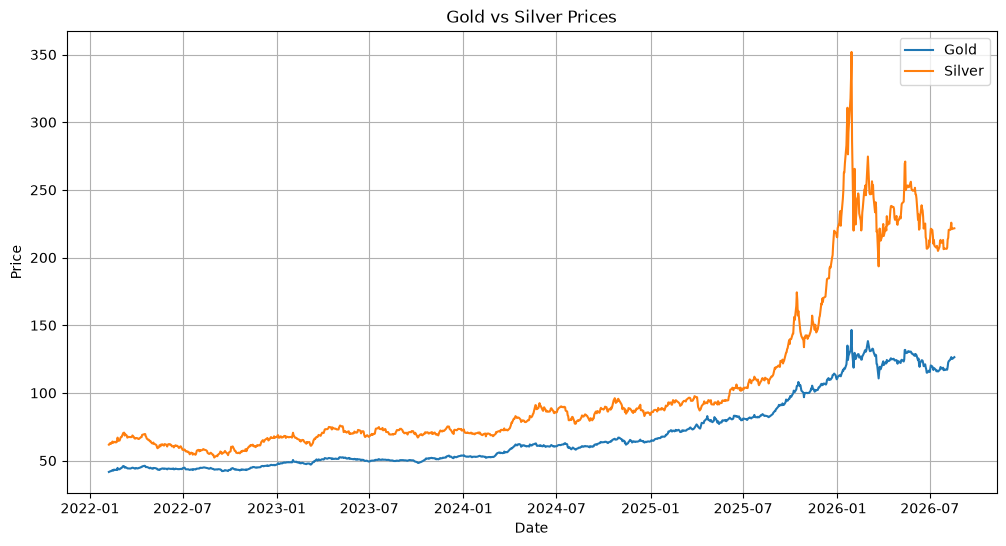

In [7]:
# ============================================
# Gold vs Silver Price Visualization
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(prices["Date"], prices["Gold"], label="Gold")
plt.plot(prices["Date"], prices["Silver"], label="Silver")

plt.title("Gold vs Silver Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ============================================
# Step 5: Engle-Granger Cointegration Test
# ============================================

# Perform the cointegration test
cointegration_result = coint(
    prices["Gold"],
    prices["Silver"]
)

# Extract results
test_statistic = cointegration_result[0]
p_value = cointegration_result[1]
critical_values = cointegration_result[2]

print("Engle-Granger Cointegration Test")
print("----------------------------------")
print("Test Statistic:", round(test_statistic, 4))
print("P-value:", round(p_value, 6))

print("\nCritical Values:")
print("1% :", round(critical_values[0], 4))
print("5% :", round(critical_values[1], 4))
print("10%:", round(critical_values[2], 4))

Engle-Granger Cointegration Test
----------------------------------
Test Statistic: -2.7629
P-value: 0.177788

Critical Values:
1% : -3.9063
5% : -3.3416
10%: -3.0482


In [9]:
# ============================================
# Step 6: Cointegration Test Using Log Prices
# ============================================

# Create log prices
prices["Log_Gold"] = np.log(prices["Gold"])
prices["Log_Silver"] = np.log(prices["Silver"])

# Perform Engle-Granger cointegration test
log_coint_result = coint(
    prices["Log_Gold"],
    prices["Log_Silver"]
)

# Extract results
log_test_statistic = log_coint_result[0]
log_p_value = log_coint_result[1]
log_critical_values = log_coint_result[2]

print("Engle-Granger Cointegration Test — Log Prices")
print("-----------------------------------------------")
print("Test Statistic:", round(log_test_statistic, 4))
print("P-value:", round(log_p_value, 6))

print("\nCritical Values:")
print("1% :", round(log_critical_values[0], 4))
print("5% :", round(log_critical_values[1], 4))
print("10%:", round(log_critical_values[2], 4))

Engle-Granger Cointegration Test — Log Prices
-----------------------------------------------
Test Statistic: -2.5174
P-value: 0.271468

Critical Values:
1% : -3.9063
5% : -3.3416
10%: -3.0482


In [11]:
# ============================================
# Step 7: Download Candidate ETF Data
# ============================================

import yfinance as yf

# Download Gold and Silver sector-related ETFs
tickers = ["XLE", "VDE"]

data = yf.download(
    tickers,
    start="2022-01-01",
    end="2026-08-19",
    auto_adjust=True
)

# Display the downloaded data
data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker            VDE        XLE        VDE        XLE        VDE        XLE   
Date                                                                           
2022-01-03  68.893341  24.452917  68.970753  24.491379  66.837723  23.739243   
2022-01-04  71.301590  25.299070  71.551017  25.397360  69.607209  24.705055   
2022-01-05  70.983360  25.294796  72.746551  25.828982  70.888750  25.256335   
2022-01-06  72.660545  25.858898  73.047584  26.004197  71.568225  25.495652   
2022-01-07  73.555031  26.213600  73.761458  26.281976  72.471320  25.777704   

Price            Open              Volume            
Ticker            VDE        XLE      VDE       XLE  
Date                                                 
2022-01-03  66.880730  23.752065  1338000  65054200  
2022-01-04  69.607209  24.786251  3049400  79957600  
2022-01-05  72.024070  25.546932  2350500  90804000  
2022-01-06  72.608935  25.888814  1791500  74681400  
2022-01-07  72.970168  25.957191  1895900  71169200

In [12]:
# ============================================
# Step 8: Prepare XLE and VDE Prices
# ============================================

# Extract adjusted/auto-adjusted closing prices
etf_prices = data["Close"].copy()

# Rename columns
etf_prices.columns = ["VDE", "XLE"]

# Remove missing values
etf_prices = etf_prices.dropna()

# Display basic information
print("Dataset shape:", etf_prices.shape)

print("\nMissing values:")
print(etf_prices.isnull().sum())

print("\nFirst 5 rows:")
display(etf_prices.head())

Dataset shape: (1160, 2)

Missing values:
VDE    0
XLE    0
dtype: int64

First 5 rows:


,VDE,XLE
Date,,
2022-01-03,68.893341,24.452917
2022-01-04,71.301590,25.299070
2022-01-05,70.983360,25.294796
2022-01-06,72.660545,25.858898
2022-01-07,73.555031,26.213600


In [13]:
# ============================================
# Step 9: XLE vs VDE Correlation
# ============================================

correlation_etf = etf_prices["XLE"].corr(etf_prices["VDE"])

print("XLE-VDE Correlation:", round(correlation_etf, 4))

XLE-VDE Correlation: 0.9995


In [14]:
# ============================================
# Step 10: Engle-Granger Cointegration Test
# XLE vs VDE
# ============================================

# Perform cointegration test
etf_coint_result = coint(
    etf_prices["XLE"],
    etf_prices["VDE"]
)

# Extract results
etf_test_statistic = etf_coint_result[0]
etf_p_value = etf_coint_result[1]
etf_critical_values = etf_coint_result[2]

print("Engle-Granger Cointegration Test — XLE vs VDE")
print("-----------------------------------------------")
print("Test Statistic:", round(etf_test_statistic, 4))
print("P-value:", round(etf_p_value, 6))

print("\nCritical Values:")
print("1% :", round(etf_critical_values[0], 4))
print("5% :", round(etf_critical_values[1], 4))
print("10%:", round(etf_critical_values[2], 4))

Engle-Granger Cointegration Test — XLE vs VDE
-----------------------------------------------
Test Statistic: -3.9429
P-value: 0.008646

Critical Values:
1% : -3.9059
5% : -3.3414
10%: -3.0481


In [15]:
# ============================================
# Step 11: Calculate Hedge Ratio
# ============================================

# Independent variable (VDE)
X = etf_prices["VDE"]

# Dependent variable (XLE)
y = etf_prices["XLE"]

# Add constant for intercept
X_with_constant = sm.add_constant(X)

# Fit linear regression
model = sm.OLS(y, X_with_constant).fit()

# Extract intercept and hedge ratio
alpha = model.params.iloc[0]
hedge_ratio = model.params.iloc[1]

print("Hedge Ratio Analysis")
print("--------------------")
print("Intercept (Alpha):", round(alpha, 6))
print("Hedge Ratio (Beta):", round(hedge_ratio, 6))

print("\nRegression R-squared:", round(model.rsquared, 6))

Hedge Ratio Analysis
--------------------
Intercept (Alpha): 0.875651
Hedge Ratio (Beta): 0.348405

Regression R-squared: 0.999053


In [16]:
# ============================================
# Step 12: Construct the Mean-Reverting Spread
# ============================================

# Calculate the spread using the hedge ratio
etf_prices["Spread"] = (
    etf_prices["XLE"]
    - hedge_ratio * etf_prices["VDE"]
)

# Display spread statistics
print("Spread Statistics")
print("------------------")
print("Mean Spread:", round(etf_prices["Spread"].mean(), 6))
print("Std Dev:", round(etf_prices["Spread"].std(), 6))
print("Minimum:", round(etf_prices["Spread"].min(), 6))
print("Maximum:", round(etf_prices["Spread"].max(), 6))

# Display first 5 rows
print("\nFirst 5 observations:")
display(etf_prices[["XLE", "VDE", "Spread"]].head())

Spread Statistics
------------------
Mean Spread: 0.875651
Std Dev: 0.215545
Minimum: 0.336482
Maximum: 1.54837

First 5 observations:


,XLE,VDE,Spread
Date,,,
2022-01-03,24.452917,68.893341,0.450103
2022-01-04,25.299070,71.301590,0.457209
2022-01-05,25.294796,70.983360,0.563807
2022-01-06,25.858898,72.660545,0.543569
2022-01-07,26.213600,73.555031,0.586628


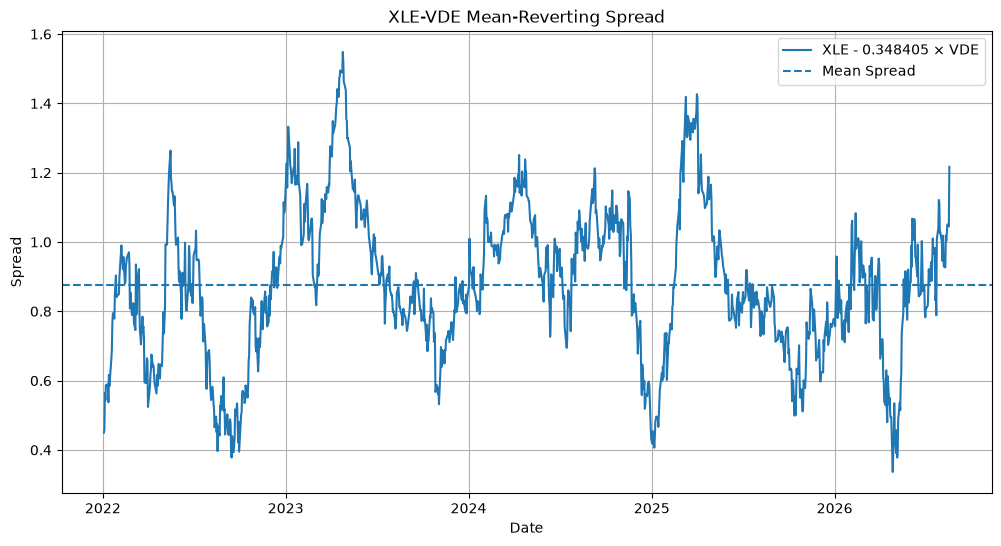

In [17]:
# ============================================
# Spread Visualization
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    etf_prices.index,
    etf_prices["Spread"],
    label="XLE - 0.348405 × VDE"
)

# Mean spread
plt.axhline(
    etf_prices["Spread"].mean(),
    linestyle="--",
    label="Mean Spread"
)

plt.title("XLE-VDE Mean-Reverting Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# ============================================
# Step 13: Augmented Dickey-Fuller Test
# ============================================

# Run ADF test on the spread
adf_result = adfuller(etf_prices["Spread"])

# Extract results
adf_statistic = adf_result[0]
adf_p_value = adf_result[1]
adf_critical_values = adf_result[4]

print("Augmented Dickey-Fuller Test")
print("----------------------------")
print("ADF Statistic:", round(adf_statistic, 6))
print("P-value:", round(adf_p_value, 6))

print("\nCritical Values:")
for key, value in adf_critical_values.items():
    print(f"{key}: {value:.6f}")

Augmented Dickey-Fuller Test
----------------------------
ADF Statistic: -3.942562
P-value: 0.001743

Critical Values:
1%: -3.436049
5%: -2.864057
10%: -2.568110


In [19]:
# ============================================
# Step 14: Calculate Rolling Z-Score
# ============================================

# Rolling window
window = 60

# Calculate rolling mean of the spread
etf_prices["Rolling_Mean"] = (
    etf_prices["Spread"]
    .rolling(window=window)
    .mean()
)

# Calculate rolling standard deviation
etf_prices["Rolling_Std"] = (
    etf_prices["Spread"]
    .rolling(window=window)
    .std()
)

# Calculate Z-score
etf_prices["Z_Score"] = (
    (etf_prices["Spread"] - etf_prices["Rolling_Mean"])
    / etf_prices["Rolling_Std"]
)

# Remove initial rows where rolling statistics aren't available
etf_prices = etf_prices.dropna().copy()

# Display results
display(
    etf_prices[
        ["XLE", "VDE", "Spread", "Rolling_Mean", "Rolling_Std", "Z_Score"]
    ].tail(10)
)

,XLE,VDE,Spread,Rolling_Mean,Rolling_Std,Z_Score
Date,,,,,,
2026-08-05,57.310001,161.570007,1.018133,0.897597,0.125681,0.959064
2026-08-06,58.160000,164.119995,0.979702,0.904986,0.116801,0.639682
2026-08-07,57.500000,162.369995,0.929411,0.911898,0.104989,0.166815
2026-08-10,60.180000,170.070007,0.926685,0.917425,0.096404,0.096062
2026-08-11,60.930000,171.960007,1.018199,0.924060,0.089009,1.057642
2026-08-12,61.029999,172.289993,1.003229,0.928426,0.086274,0.867040
2026-08-13,61.060001,172.300003,1.029744,0.932365,0.085395,1.140337
2026-08-14,61.910000,174.679993,1.050541,0.934997,0.086574,1.334619
2026-08-17,62.580002,176.619995,1.044636,0.938653,0.086495,1.225310


In [20]:
# ============================================
# Step 15: Generate Trading Signals
# ============================================

# Initialize signal column
etf_prices["Signal"] = 0

# Short spread:
# Short XLE and Long VDE
etf_prices.loc[etf_prices["Z_Score"] >= 2, "Signal"] = -1

# Long spread:
# Long XLE and Short VDE
etf_prices.loc[etf_prices["Z_Score"] <= -2, "Signal"] = 1

# Count signals
print("Trading Signal Summary")
print("-----------------------")
print("Long Spread Signals :", (etf_prices["Signal"] == 1).sum())
print("Short Spread Signals:", (etf_prices["Signal"] == -1).sum())
print("No Signal           :", (etf_prices["Signal"] == 0).sum())

Trading Signal Summary
-----------------------
Long Spread Signals : 75
Short Spread Signals: 69
No Signal           : 957


In [21]:
# ============================================
# Step 16: Backtest the Mean-Reversion Strategy
# ============================================

# Calculate daily percentage returns
etf_prices["XLE_Return"] = etf_prices["XLE"].pct_change()
etf_prices["VDE_Return"] = etf_prices["VDE"].pct_change()

# Use the previous day's signal to avoid look-ahead bias
etf_prices["Position"] = etf_prices["Signal"].shift(1).fillna(0)

# Calculate spread strategy return
#
# Signal = +1:
# Long XLE + Short VDE
#
# Signal = -1:
# Short XLE + Long VDE
#
# The hedge ratio determines the VDE exposure.
etf_prices["Strategy_Return"] = (
    etf_prices["Position"]
    * (
        etf_prices["XLE_Return"]
        - hedge_ratio * etf_prices["VDE_Return"]
    )
)

# Replace missing values
etf_prices["Strategy_Return"] = (
    etf_prices["Strategy_Return"].fillna(0)
)

# Calculate cumulative strategy return
etf_prices["Cumulative_Strategy_Return"] = (
    (1 + etf_prices["Strategy_Return"]).cumprod() - 1
)

# Display latest results
display(
    etf_prices[
        [
            "XLE_Return",
            "VDE_Return",
            "Signal",
            "Position",
            "Strategy_Return",
            "Cumulative_Strategy_Return"
        ]
    ].tail(10)
)

,XLE_Return,VDE_Return,Signal,Position,Strategy_Return,Cumulative_Strategy_Return
Date,,,,,,
2026-08-05,-0.020677,-0.022269,0,0.0,-0.0,-0.01297
2026-08-06,0.014832,0.015783,0,0.0,0.0,-0.01297
2026-08-07,-0.011348,-0.010663,0,0.0,-0.0,-0.01297
2026-08-10,0.046609,0.047423,0,0.0,0.0,-0.01297
2026-08-11,0.012463,0.011113,0,0.0,0.0,-0.01297
2026-08-12,0.001641,0.001919,0,0.0,0.0,-0.01297
2026-08-13,0.000492,0.000058,0,0.0,0.0,-0.01297
2026-08-14,0.013921,0.013813,0,0.0,0.0,-0.01297
2026-08-17,0.010822,0.011106,0,0.0,0.0,-0.01297


In [22]:
# ============================================
# Step 17: Strategy Performance Metrics
# ============================================

# Remove any missing returns
strategy_returns = etf_prices["Strategy_Return"].dropna()

# Total cumulative return
total_return = (
    (1 + strategy_returns).prod() - 1
)

# Annualized return
trading_days = 252

annualized_return = (
    (1 + total_return)
    ** (trading_days / len(strategy_returns))
    - 1
)

# Annualized volatility
annualized_volatility = (
    strategy_returns.std() * np.sqrt(trading_days)
)

# Sharpe Ratio
sharpe_ratio = (
    annualized_return / annualized_volatility
    if annualized_volatility != 0 else np.nan
)

# Calculate drawdown
cumulative = (1 + strategy_returns).cumprod()

running_max = cumulative.cummax()

drawdown = (
    cumulative / running_max - 1
)

maximum_drawdown = drawdown.min()

# Win rate
winning_days = (strategy_returns > 0).sum()
total_trading_days = (strategy_returns != 0).sum()

win_rate = (
    winning_days / total_trading_days
    if total_trading_days > 0 else np.nan
)

print("Mean-Reversion Strategy Performance")
print("-------------------------------------")
print("Total Return       :", round(total_return * 100, 2), "%")
print("Annualized Return  :", round(annualized_return * 100, 2), "%")
print("Annualized Volatility:", round(annualized_volatility * 100, 2), "%")
print("Sharpe Ratio       :", round(sharpe_ratio, 4))
print("Maximum Drawdown   :", round(maximum_drawdown * 100, 2), "%")
print("Win Rate           :", round(win_rate * 100, 2), "%")

Mean-Reversion Strategy Performance
-------------------------------------
Total Return       : -1.3 %
Annualized Return  : -0.3 %
Annualized Volatility: 5.07 %
Sharpe Ratio       : -0.0589
Maximum Drawdown   : -10.96 %
Win Rate           : 47.55 %


In [23]:
# ============================================
# Step 18: Proper Mean-Reversion Positions
# ============================================

# Create a copy for the improved backtest
backtest = etf_prices.copy()

# Position:
# +1 = Long XLE / Short VDE
# -1 = Short XLE / Long VDE
#  0 = No position

backtest["Position"] = 0

current_position = 0

for i in range(len(backtest)):

    z = backtest["Z_Score"].iloc[i]

    # Enter LONG spread
    if current_position == 0 and z <= -2:
        current_position = 1

    # Enter SHORT spread
    elif current_position == 0 and z >= 2:
        current_position = -1

    # Exit when spread returns to the mean
    elif current_position == 1 and z >= 0:
        current_position = 0

    elif current_position == -1 and z <= 0:
        current_position = 0

    backtest.iloc[i, backtest.columns.get_loc("Position")] = current_position

# Display recent observations
display(
    backtest[
        ["Spread", "Z_Score", "Position"]
    ].tail(20)
)

,Spread,Z_Score,Position
Date,,,
2026-07-22,0.845573,0.222958,0
2026-07-23,0.788660,-0.100390,0
2026-07-24,1.007754,1.015425,0
2026-07-27,1.040337,1.167931,0
2026-07-28,1.121350,1.563552,0
2026-07-29,1.114328,1.494970,0
2026-07-30,1.027144,0.994218,0
2026-07-31,1.028338,0.986880,0
2026-08-03,0.999993,0.810072,0


In [25]:
# ============================================
# Step 19: Improved Strategy Backtest - FIXED
# ============================================

# Make sure we are working with a fresh copy
backtest = etf_prices.copy()

# --------------------------------------------
# 1. Calculate daily returns
# --------------------------------------------

backtest["XLE_Return"] = backtest["XLE"].pct_change()
backtest["VDE_Return"] = backtest["VDE"].pct_change()

# --------------------------------------------
# 2. Use previous day's position
# --------------------------------------------

backtest["Previous_Position"] = (
    backtest["Position"].shift(1).fillna(0)
)

# --------------------------------------------
# 3. Calculate strategy return
# --------------------------------------------

backtest["Strategy_Return"] = (
    backtest["Previous_Position"]
    * (
        backtest["XLE_Return"]
        - hedge_ratio * backtest["VDE_Return"]
    )
)

# Replace missing values with zero
backtest["Strategy_Return"] = (
    backtest["Strategy_Return"].fillna(0)
)

# --------------------------------------------
# 4. Calculate cumulative strategy return
# --------------------------------------------

backtest["Cumulative_Return"] = (
    (1 + backtest["Strategy_Return"]).cumprod() - 1
)

# --------------------------------------------
# 5. Display results
# --------------------------------------------

display(
    backtest[
        [
            "XLE",
            "VDE",
            "Z_Score",
            "Position",
            "Previous_Position",
            "Strategy_Return",
            "Cumulative_Return"
        ]
    ].tail(10)
)

,XLE,VDE,Z_Score,Position,Previous_Position,Strategy_Return,Cumulative_Return
Date,,,,,,,
2026-08-05,57.310001,161.570007,0.959064,0.0,0.0,-0.0,-0.033391
2026-08-06,58.160000,164.119995,0.639682,0.0,0.0,0.0,-0.033391
2026-08-07,57.500000,162.369995,0.166815,0.0,0.0,-0.0,-0.033391
2026-08-10,60.180000,170.070007,0.096062,0.0,0.0,0.0,-0.033391
2026-08-11,60.930000,171.960007,1.057642,0.0,0.0,0.0,-0.033391
2026-08-12,61.029999,172.289993,0.867040,0.0,0.0,0.0,-0.033391
2026-08-13,61.060001,172.300003,1.140337,0.0,0.0,0.0,-0.033391
2026-08-14,61.910000,174.679993,1.334619,0.0,0.0,0.0,-0.033391
2026-08-17,62.580002,176.619995,1.225310,0.0,0.0,0.0,-0.033391


In [26]:
# ============================================
# Step 20: Improved Performance Metrics - FIXED
# ============================================

returns = backtest["Strategy_Return"].dropna()

# --------------------------------------------
# Total Return
# --------------------------------------------

total_return = (
    (1 + returns).prod() - 1
)

# --------------------------------------------
# Annualized Return
# --------------------------------------------

annualized_return = (
    (1 + total_return)
    ** (252 / len(returns))
    - 1
)

# --------------------------------------------
# Annualized Volatility
# --------------------------------------------

annualized_volatility = (
    returns.std() * np.sqrt(252)
)

# --------------------------------------------
# Sharpe Ratio
# --------------------------------------------

sharpe_ratio = (
    annualized_return / annualized_volatility
    if annualized_volatility != 0
    else np.nan
)

# --------------------------------------------
# Maximum Drawdown
# --------------------------------------------

cumulative = (
    1 + returns
).cumprod()

running_max = cumulative.cummax()

drawdown = (
    cumulative / running_max - 1
)

maximum_drawdown = drawdown.min()

# --------------------------------------------
# Win Rate
# --------------------------------------------

active_returns = backtest.loc[
    backtest["Previous_Position"] != 0,
    "Strategy_Return"
]

winning_days = (
    active_returns > 0
).sum()

active_days = len(active_returns)

win_rate = (
    winning_days / active_days
    if active_days > 0
    else np.nan
)

# --------------------------------------------
# Number of Entries
# --------------------------------------------

entries = (
    (backtest["Position"] != 0)
    &
    (backtest["Position"].shift(1).fillna(0) == 0)
).sum()

# --------------------------------------------
# Print results
# --------------------------------------------

print("IMPROVED MEAN-REVERSION STRATEGY")
print("=================================")
print("Total Return          :", round(total_return * 100, 2), "%")
print("Annualized Return     :", round(annualized_return * 100, 2), "%")
print("Annualized Volatility :", round(annualized_volatility * 100, 2), "%")
print("Sharpe Ratio          :", round(sharpe_ratio, 4))
print("Maximum Drawdown      :", round(maximum_drawdown * 100, 2), "%")
print("Win Rate              :", round(win_rate * 100, 2), "%")
print("Number of Entries     :", entries)
print("Active Trading Days   :", active_days)

IMPROVED MEAN-REVERSION STRATEGY
Total Return          : -3.34 %
Annualized Return     : -0.77 %
Annualized Volatility : 5.04 %
Sharpe Ratio          : -0.1536
Maximum Drawdown      : -11.18 %
Win Rate              : 44.76 %
Number of Entries     : 45
Active Trading Days   : 143


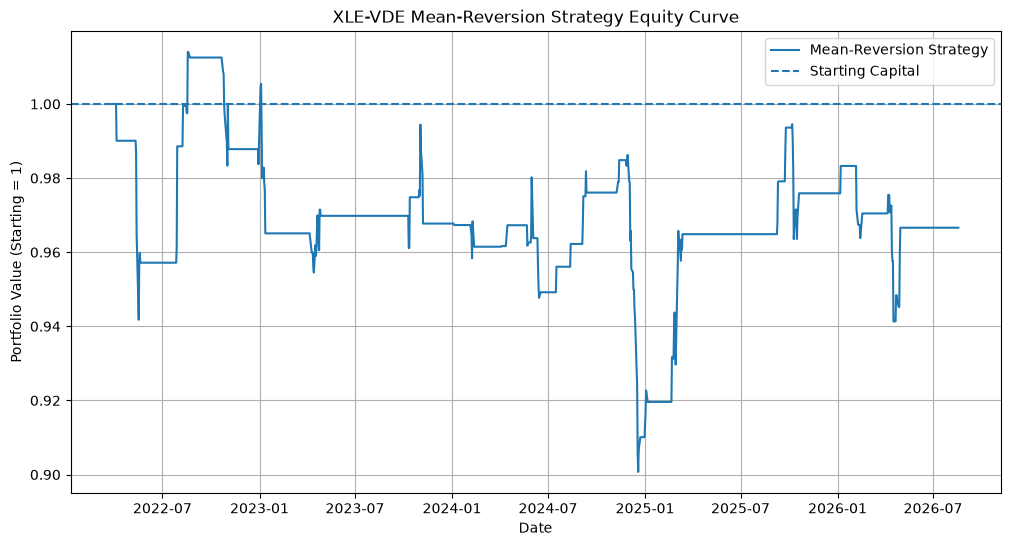

In [27]:
# ============================================
# Step 21: Strategy Equity Curve
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    backtest.index,
    (1 + backtest["Strategy_Return"]).cumprod(),
    label="Mean-Reversion Strategy"
)

plt.axhline(
    1,
    linestyle="--",
    label="Starting Capital"
)

plt.title("XLE-VDE Mean-Reversion Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Starting = 1)")
plt.legend()
plt.grid(True)

plt.show()

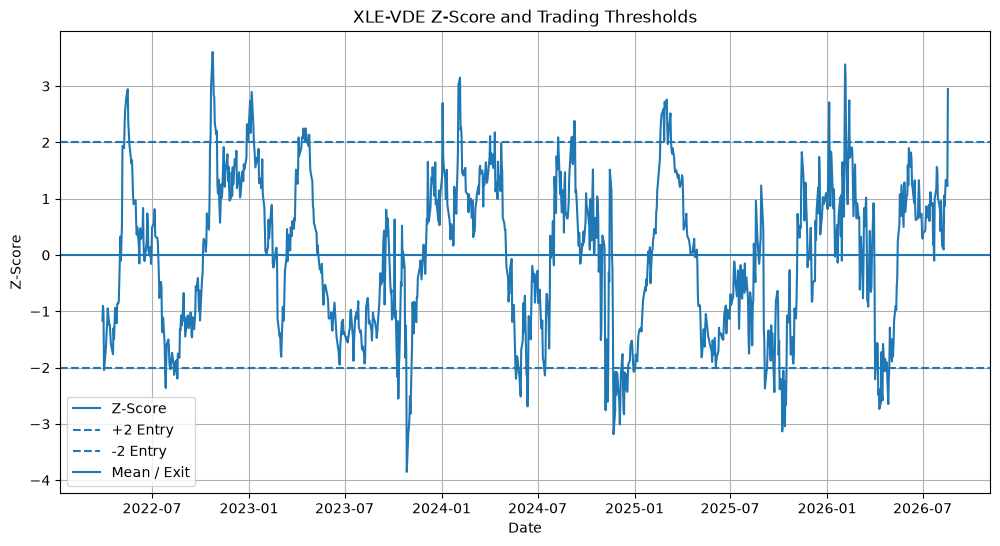

In [28]:
# ============================================
# Step 22: Z-Score and Trading Positions
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    backtest.index,
    backtest["Z_Score"],
    label="Z-Score"
)

# Entry thresholds
plt.axhline(
    2,
    linestyle="--",
    label="+2 Entry"
)

plt.axhline(
    -2,
    linestyle="--",
    label="-2 Entry"
)

# Mean
plt.axhline(
    0,
    linestyle="-",
    label="Mean / Exit"
)

plt.title("XLE-VDE Z-Score and Trading Thresholds")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# ============================================
# Step 23: Dollar-Neutral Portfolio Weights
# ============================================

# Calculate normalized portfolio weights
weight_xle = 1 / (1 + hedge_ratio)
weight_vde = hedge_ratio / (1 + hedge_ratio)

print("Portfolio Construction")
print("----------------------")
print("Hedge Ratio:", round(hedge_ratio, 6))
print("XLE Weight :", round(weight_xle * 100, 2), "%")
print("VDE Weight :", round(weight_vde * 100, 2), "%")

print("\nLong Spread:")
print("Long XLE  :", round(weight_xle * 100, 2), "%")
print("Short VDE :", round(weight_vde * 100, 2), "%")

print("\nShort Spread:")
print("Short XLE :", round(weight_xle * 100, 2), "%")
print("Long VDE  :", round(weight_vde * 100, 2), "%")

Portfolio Construction
----------------------
Hedge Ratio: 0.348405
XLE Weight : 74.16 %
VDE Weight : 25.84 %

Long Spread:
Long XLE  : 74.16 %
Short VDE : 25.84 %

Short Spread:
Short XLE : 74.16 %
Long VDE  : 25.84 %


In [30]:
# ============================================
# Step 24: Weighted Mean-Reversion Backtest
# ============================================

# Make a fresh copy
final_backtest = backtest.copy()

# Calculate daily returns
final_backtest["XLE_Return"] = final_backtest["XLE"].pct_change()
final_backtest["VDE_Return"] = final_backtest["VDE"].pct_change()

# Use previous day's position
final_backtest["Previous_Position"] = (
    final_backtest["Position"].shift(1).fillna(0)
)

# Calculate weighted portfolio return
final_backtest["Strategy_Return"] = (
    final_backtest["Previous_Position"]
    * (
        weight_xle * final_backtest["XLE_Return"]
        - weight_vde * final_backtest["VDE_Return"]
    )
)

# Remove missing values
final_backtest["Strategy_Return"] = (
    final_backtest["Strategy_Return"].fillna(0)
)

# Calculate cumulative return
final_backtest["Cumulative_Return"] = (
    (1 + final_backtest["Strategy_Return"]).cumprod() - 1
)

# Display latest results
display(
    final_backtest[
        [
            "XLE",
            "VDE",
            "Z_Score",
            "Position",
            "Previous_Position",
            "Strategy_Return",
            "Cumulative_Return"
        ]
    ].tail(10)
)


,XLE,VDE,Z_Score,Position,Previous_Position,Strategy_Return,Cumulative_Return
Date,,,,,,,
2026-08-05,57.310001,161.570007,0.959064,0.0,0.0,-0.0,-0.023836
2026-08-06,58.160000,164.119995,0.639682,0.0,0.0,0.0,-0.023836
2026-08-07,57.500000,162.369995,0.166815,0.0,0.0,-0.0,-0.023836
2026-08-10,60.180000,170.070007,0.096062,0.0,0.0,0.0,-0.023836
2026-08-11,60.930000,171.960007,1.057642,0.0,0.0,0.0,-0.023836
2026-08-12,61.029999,172.289993,0.867040,0.0,0.0,0.0,-0.023836
2026-08-13,61.060001,172.300003,1.140337,0.0,0.0,0.0,-0.023836
2026-08-14,61.910000,174.679993,1.334619,0.0,0.0,0.0,-0.023836
2026-08-17,62.580002,176.619995,1.225310,0.0,0.0,0.0,-0.023836


In [31]:
# ============================================
# Step 25: Final Performance Metrics
# ============================================

returns = final_backtest["Strategy_Return"].dropna()

# Total return
total_return = (1 + returns).prod() - 1

# Annualized return
annualized_return = (
    (1 + total_return)
    ** (252 / len(returns))
    - 1
)

# Annualized volatility
annualized_volatility = (
    returns.std() * np.sqrt(252)
)

# Sharpe ratio
sharpe_ratio = (
    annualized_return / annualized_volatility
    if annualized_volatility != 0
    else np.nan
)

# Maximum drawdown
cumulative = (1 + returns).cumprod()
running_max = cumulative.cummax()

drawdown = cumulative / running_max - 1
maximum_drawdown = drawdown.min()

# Active trading days
active_returns = final_backtest.loc[
    final_backtest["Previous_Position"] != 0,
    "Strategy_Return"
]

winning_days = (active_returns > 0).sum()
active_days = len(active_returns)

win_rate = (
    winning_days / active_days
    if active_days > 0
    else np.nan
)

# Number of entries
entries = (
    (final_backtest["Position"] != 0)
    &
    (final_backtest["Position"].shift(1).fillna(0) == 0)
).sum()

print("FINAL WEIGHTED MEAN-REVERSION STRATEGY")
print("========================================")
print("Total Return          :", round(total_return * 100, 2), "%")
print("Annualized Return     :", round(annualized_return * 100, 2), "%")
print("Annualized Volatility :", round(annualized_volatility * 100, 2), "%")
print("Sharpe Ratio          :", round(sharpe_ratio, 4))
print("Maximum Drawdown      :", round(maximum_drawdown * 100, 2), "%")
print("Win Rate              :", round(win_rate * 100, 2), "%")
print("Number of Entries     :", entries)
print("Active Trading Days   :", active_days)

FINAL WEIGHTED MEAN-REVERSION STRATEGY
Total Return          : -2.38 %
Annualized Return     : -0.55 %
Annualized Volatility : 3.74 %
Sharpe Ratio          : -0.1473
Maximum Drawdown      : -8.37 %
Win Rate              : 44.76 %
Number of Entries     : 45
Active Trading Days   : 143


In [32]:
# ============================================
# Step 26: Transaction Costs
# ============================================

# Assumption:
# 10 basis points = 0.10% per ETF transaction
transaction_cost = 0.001

# Detect changes in position
position_change = (
    final_backtest["Position"]
    .diff()
    .abs()
    .fillna(0)
)

# Transaction cost is charged whenever position changes
final_backtest["Transaction_Cost"] = (
    position_change * transaction_cost
)

# Strategy return after transaction costs
final_backtest["Net_Strategy_Return"] = (
    final_backtest["Strategy_Return"]
    - final_backtest["Transaction_Cost"]
)

# Cumulative net return
final_backtest["Net_Cumulative_Return"] = (
    (1 + final_backtest["Net_Strategy_Return"])
    .cumprod() - 1
)

# Total transaction costs
total_transaction_cost = (
    final_backtest["Transaction_Cost"].sum()
)

print("Transaction Cost Analysis")
print("==========================")
print("Transaction cost per trade:", transaction_cost * 100, "%")
print(
    "Total transaction costs:",
    round(total_transaction_cost * 100, 2),
    "%"
)

Transaction Cost Analysis
Transaction cost per trade: 0.1 %
Total transaction costs: 9.0 %


In [33]:
# ============================================
# Step 27: Final After-Cost Performance
# ============================================

net_returns = (
    final_backtest["Net_Strategy_Return"]
    .dropna()
)

# Total return
net_total_return = (
    (1 + net_returns).prod() - 1
)

# Annualized return
net_annualized_return = (
    (1 + net_total_return)
    ** (252 / len(net_returns))
    - 1
)

# Annualized volatility
net_volatility = (
    net_returns.std() * np.sqrt(252)
)

# Sharpe ratio
net_sharpe = (
    net_annualized_return / net_volatility
    if net_volatility != 0
    else np.nan
)

# Maximum drawdown
net_cumulative = (
    1 + net_returns
).cumprod()

net_running_max = (
    net_cumulative.cummax()
)

net_drawdown = (
    net_cumulative / net_running_max - 1
)

net_max_drawdown = net_drawdown.min()

print("FINAL AFTER-COST PERFORMANCE")
print("============================")
print("Total Return       :", round(net_total_return * 100, 2), "%")
print("Annualized Return  :", round(net_annualized_return * 100, 2), "%")
print("Annualized Volatility:", round(net_volatility * 100, 2), "%")
print("Sharpe Ratio       :", round(net_sharpe, 4))
print("Maximum Drawdown   :", round(net_max_drawdown * 100, 2), "%")
print(
    "Total Transaction Costs:",
    round(total_transaction_cost * 100, 2),
    "%"
)

FINAL AFTER-COST PERFORMANCE
Total Return       : -10.79 %
Annualized Return  : -2.58 %
Annualized Volatility: 3.74 %
Sharpe Ratio       : -0.6898
Maximum Drawdown   : -12.7 %
Total Transaction Costs: 9.0 %


In [34]:
# ============================================
# Step 28: Train-Test Split
# ============================================

split_index = int(len(etf_prices) * 0.70)

train = etf_prices.iloc[:split_index].copy()
test = etf_prices.iloc[split_index:].copy()

print("Train observations:", len(train))
print("Test observations :", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Train observations: 770
Test observations : 331

Training period:
2022-03-29 00:00:00 to 2025-04-23 00:00:00

Testing period:
2025-04-24 00:00:00 to 2026-08-18 00:00:00


In [35]:
# ============================================
# Step 29: Training-Period Cointegration
# ============================================

train_coint = coint(
    train["XLE"],
    train["VDE"]
)

print("TRAINING PERIOD COINTEGRATION")
print("=============================")
print("Test Statistic:", round(train_coint[0], 4))
print("P-value:", round(train_coint[1], 6))

print("\nCritical Values:")
print("1% :", round(train_coint[2][0], 4))
print("5% :", round(train_coint[2][1], 4))
print("10%:", round(train_coint[2][2], 4))

TRAINING PERIOD COINTEGRATION
Test Statistic: -3.0652
P-value: 0.095511

Critical Values:
1% : -3.9107
5% : -3.3441
10%: -3.05


In [36]:
# ============================================
# Step 30: Training Spread & ADF Test
# ============================================

# Calculate training hedge ratio
X_train = sm.add_constant(train["VDE"])

train_model = sm.OLS(
    train["XLE"],
    X_train
).fit()

train_beta = train_model.params.iloc[1]

# Construct training spread
train["Spread"] = (
    train["XLE"]
    - train_beta * train["VDE"]
)

# ADF test
train_adf = adfuller(
    train["Spread"]
)

print("TRAINING PERIOD ADF TEST")
print("========================")
print("Hedge Ratio:", round(train_beta, 6))
print("ADF Statistic:", round(train_adf[0], 6))
print("P-value:", round(train_adf[1], 6))

print("\nCritical Values:")

for key, value in train_adf[4].items():
    print(f"{key}: {value:.6f}")

TRAINING PERIOD ADF TEST
Hedge Ratio: 0.353302
ADF Statistic: -3.062554
P-value: 0.029451

Critical Values:
1%: -3.438984
5%: -2.865350
10%: -2.568799


In [37]:
# ============================================
# FINAL: Out-of-Sample Test
# ============================================

# Use the test-period data
test = test.copy()

# Use the hedge ratio estimated ONLY from training data
test["Spread"] = (
    test["XLE"] - train_beta * test["VDE"]
)

# Test stationarity of the unseen test-period spread
test_adf = adfuller(test["Spread"])

print("OUT-OF-SAMPLE ADF TEST")
print("======================")
print("ADF Statistic:", round(test_adf[0], 6))
print("P-value:", round(test_adf[1], 6))

print("\nCritical Values:")
for key, value in test_adf[4].items():
    print(f"{key}: {value:.6f}")

OUT-OF-SAMPLE ADF TEST
ADF Statistic: -3.117642
P-value: 0.025275

Critical Values:
1%: -3.450384
5%: -2.870365
10%: -2.571472
